# Retail Intelligence & Recommendation System using Instacart Data
## Notebook 2: Market Basket Analysis

This notebook applies association rule mining algorithms (**Apriori** and **FP-Growth**) on Instacart basket data. We will compare their runtime, extract rules, and visualize them using network graphs and heatmaps to derive actionable business insights.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import time
from pathlib import Path
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


### 1. Data Preparation
We load the master dataframe (using our 5,000 customer downsampled set) and create a transaction list of product names grouped by order.

In [2]:
data_dir = Path("../../datasets/instacart_market_ basket")
orders = pd.read_csv(data_dir / "orders.csv")
orders = orders[orders['user_id'] <= 5000]
order_ids = set(orders['order_id'])

op_prior = pd.read_csv(data_dir / "order_products__prior.csv")
op_prior = op_prior[op_prior['order_id'].isin(order_ids)]
products = pd.read_csv(data_dir / "products.csv")

df = op_prior.merge(products, on='product_id')

# Group by order_id to create transactions
transactions = df.groupby('order_id')['product_name'].apply(list).values.tolist()
print(f"Number of transactions: {len(transactions)}")
print("Example Transaction:", transactions[0])

Number of transactions: 76832
Example Transaction: ['Original Hawaiian Sweet Rolls']


#### Transaction Encoding
We transform the transaction list into a binary matrix format expected by the `mlxtend` package. To avoid memory bottlenecks and focus on popular item association rules, we filter out products that appear less than 50 times in total.

In [3]:
# To run Apriori & FP-Growth extremely fast, let's keep only products that are reasonably frequent (>= 50 purchases)
product_counts = df['product_name'].value_counts()
frequent_product_names = set(product_counts[product_counts >= 50].index)

filtered_transactions = [
    [item for item in tx if item in frequent_product_names] 
    for tx in transactions
]
# Filter out empty transactions
filtered_transactions = [tx for tx in filtered_transactions if len(tx) > 0]

te = TransactionEncoder()
te_ary = te.fit(filtered_transactions).transform(filtered_transactions)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)
print(f"Encoded Basket DataFrame shape: {basket_df.shape}")

Encoded Basket DataFrame shape: (74461, 2779)


### 2. Algorithm Comparison: Apriori vs FP-Growth
We run both algorithms to generate frequent itemsets and compare execution speed.

In [4]:
min_support = 0.005

# 1. Apriori
start_time = time.time()
frequent_itemsets_apriori = apriori(basket_df, min_support=min_support, use_colnames=True)
apriori_time = time.time() - start_time
print(f"Apriori found {len(frequent_itemsets_apriori)} itemsets in {apriori_time:.4f} seconds.")

# 2. FP-Growth
start_time = time.time()
frequent_itemsets_fpgrowth = fpgrowth(basket_df, min_support=min_support, use_colnames=True)
fpgrowth_time = time.time() - start_time
print(f"FP-Growth found {len(frequent_itemsets_fpgrowth)} itemsets in {fpgrowth_time:.4f} seconds.")
print(f"FP-Growth is {apriori_time / fpgrowth_time:.1f}x faster than Apriori on this dataset!")

Apriori found 344 itemsets in 19.8937 seconds.
FP-Growth found 344 itemsets in 4.6321 seconds.
FP-Growth is 4.3x faster than Apriori on this dataset!


### 3. Rule Generation
We generate association rules from the frequent itemsets using a minimum lift threshold of 1.2.

In [5]:
rules = association_rules(frequent_itemsets_fpgrowth, metric="lift", min_threshold=1.2)
rules = rules.sort_values(by="lift", ascending=False).reset_index(drop=True)

# Convert antecedents and consequents from frozenset to comma-separated strings for readability
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

print(f"Generated {len(rules)} association rules.")
rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(15)

Generated 154 association rules.


,antecedents_str,consequents_str,support,confidence,lift
0,Organic Cilantro,Limes,0.005479,0.262887,5.846714
1,Limes,Organic Cilantro,0.005479,0.121864,5.846714
2,Organic Yellow Onion,Organic Garlic,0.006540,0.198532,5.670472
3,Organic Garlic,Organic Yellow Onion,0.006540,0.186805,5.670472
4,"Organic Strawberries, Bag of Organic Bananas",Organic Hass Avocado,0.005654,0.275524,3.905532
5,Organic Hass Avocado,"Organic Strawberries, Bag of Organic Bananas",0.005654,0.080145,3.905532
6,Large Lemon,Limes,0.008192,0.160653,3.572997
7,Limes,Large Lemon,0.008192,0.182198,3.572997
8,Organic Raspberries,Organic Blueberries,0.005587,0.116854,3.567471
9,Organic Blueberries,Organic Raspberries,0.005587,0.170562,3.567471


### 4. Rule Visualizations

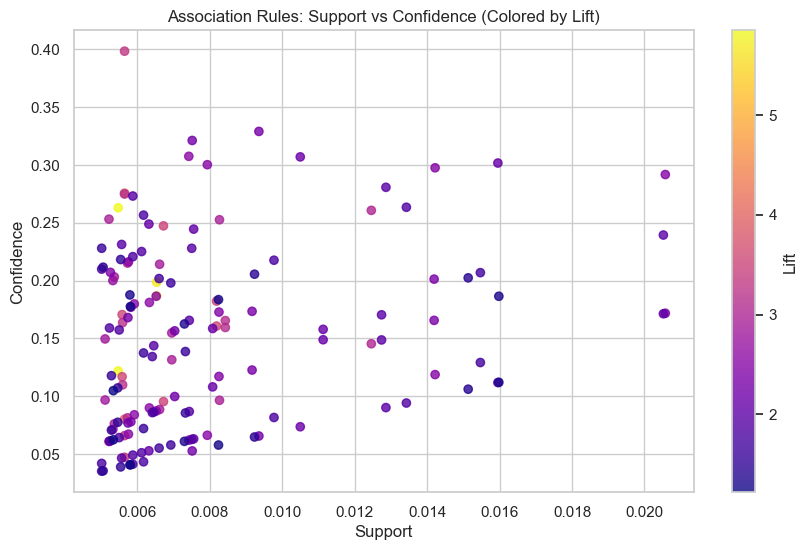

In [6]:
# Scatter plot: Support vs Confidence (colored by Lift)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='plasma', alpha=0.8)
plt.colorbar(scatter, label='Lift')
plt.title('Association Rules: Support vs Confidence (Colored by Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

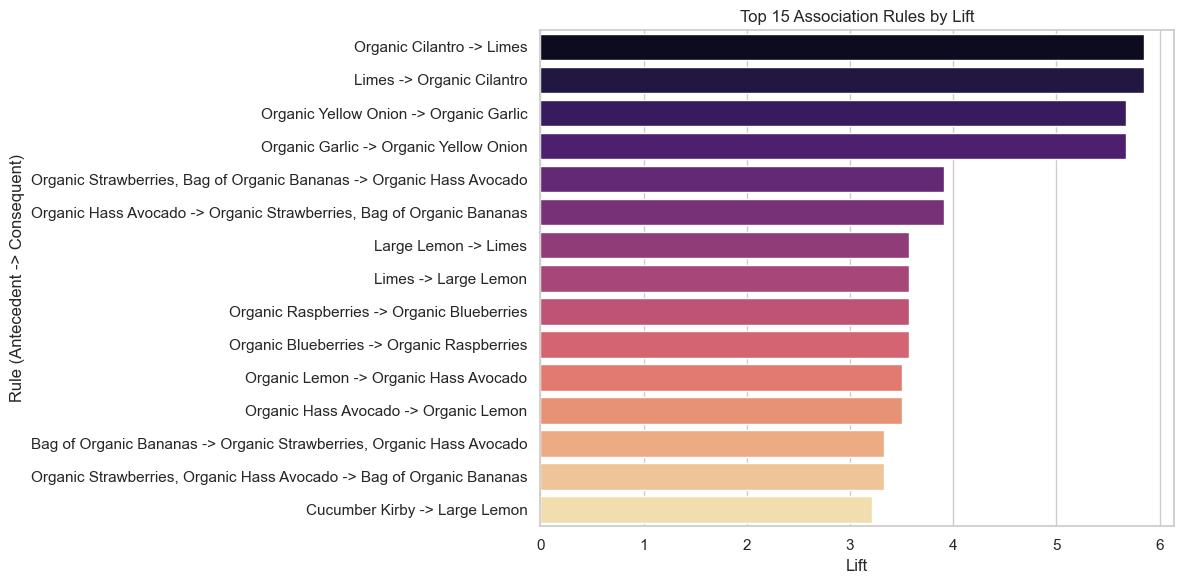

In [7]:
# Bar plot: Top 15 rules sorted by Lift
plt.figure(figsize=(12, 6))
top_15_rules = rules.head(15)
rule_names = top_15_rules['antecedents_str'] + ' -> ' + top_15_rules['consequents_str']
sns.barplot(x=top_15_rules['lift'], y=rule_names, palette='magma')
plt.title('Top 15 Association Rules by Lift')
plt.xlabel('Lift')
plt.ylabel('Rule (Antecedent -> Consequent)')
plt.tight_layout()
plt.show()

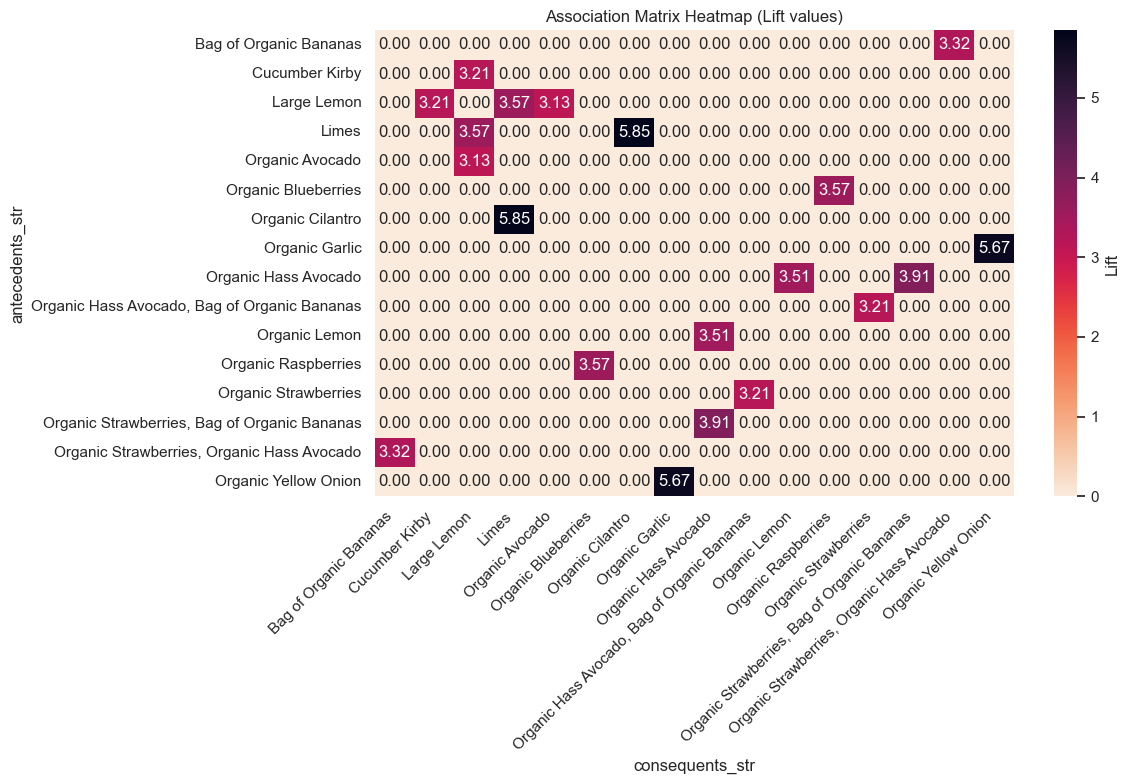

In [8]:
# Heatmap of associations among top frequent products
# Pivot top rules into an association table
top_20_rules = rules.head(20)
pivot_rules = top_20_rules.pivot(index='antecedents_str', columns='consequents_str', values='lift').fillna(0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_rules, cmap='rocket_r', annot=True, fmt=".2f", cbar_kws={'label': 'Lift'})
plt.title('Association Matrix Heatmap (Lift values)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

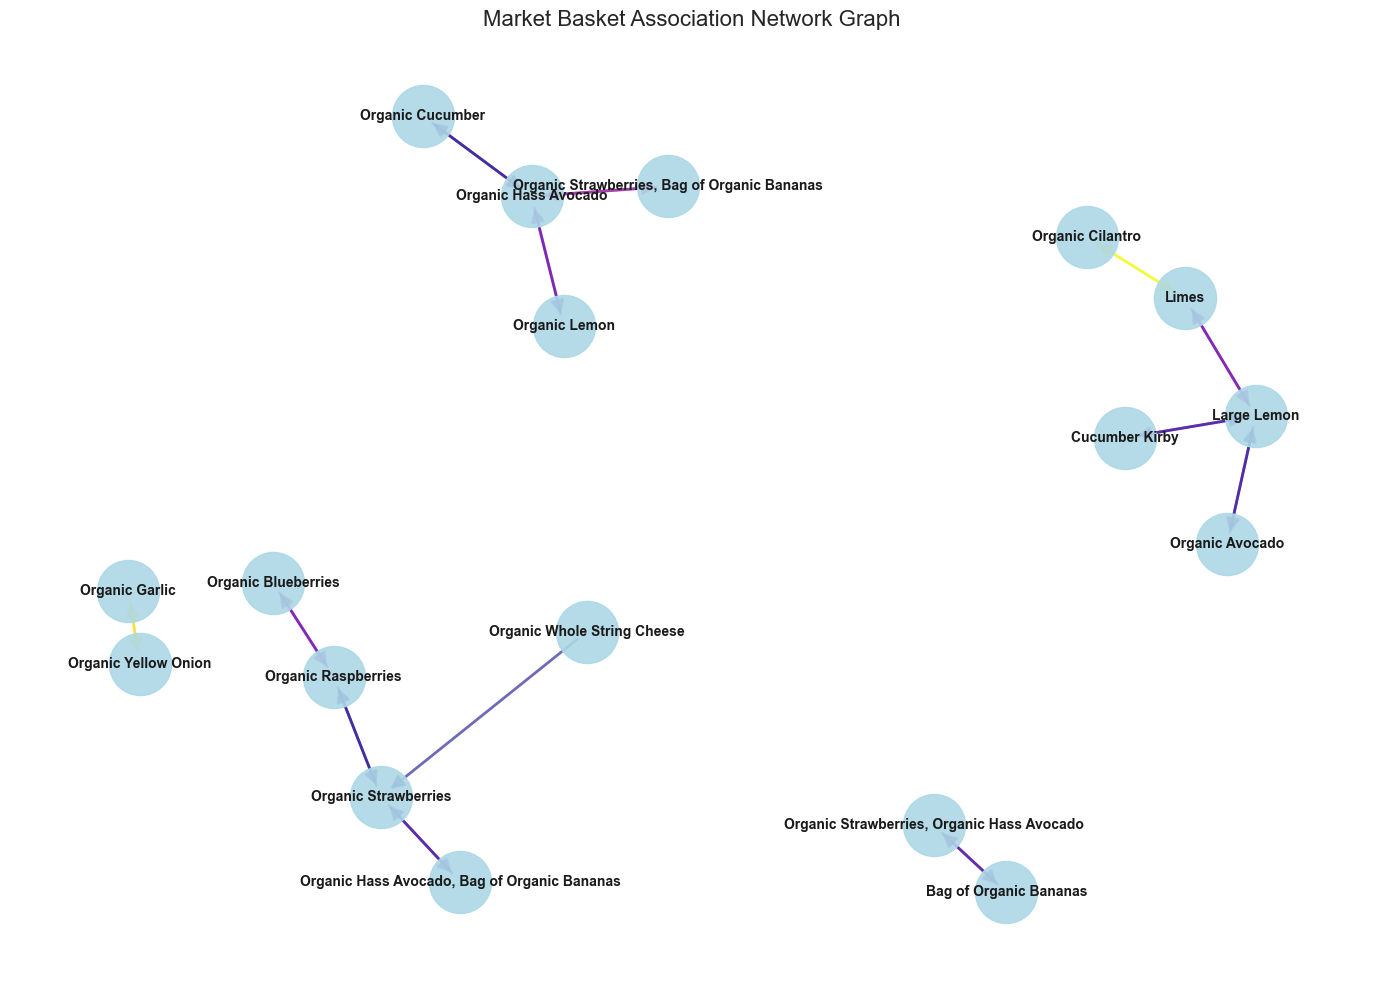

In [9]:
# Network Graph of top rules
plt.figure(figsize=(14, 10))
G = nx.DiGraph()

# Add edges for top 25 rules
for idx, row in rules.head(25).iterrows():
    G.add_edge(row['antecedents_str'], row['consequents_str'], weight=row['lift'])

pos = nx.spring_layout(G, k=0.8, seed=42)
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="lightblue", alpha=0.9)
nx.draw_networkx_edges(G, pos, width=2, alpha=0.6, edge_color=weights, edge_cmap=plt.cm.plasma, arrowsize=20)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

plt.title('Market Basket Association Network Graph', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

### 5. Business Questions & Outcomes
Let's check specific rules:
1. **Organic Bananas / Bananas co-occurrence:** Bananas are very often co-purchased with other fruits like organic strawberries.
2. **Baby / Diapers:** Do shoppers buying baby items also buy wipes?

In [10]:
# Search for baby products / wipes rules
baby_rules = rules[rules['antecedents_str'].str.contains('baby|diaper|wipe|infant', case=False) | 
                   rules['consequents_str'].str.contains('baby|diaper|wipe|infant', case=False)]
print("Baby & Diapers/Wipes Related Rules:")
print(baby_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(10))

# Search for Bananas and Strawberries
banana_rules = rules[rules['antecedents_str'].str.contains('Banana', case=False) & 
                     rules['consequents_str'].str.contains('Strawberries', case=False)]
print("\nBananas & Strawberries Association Rules:")
print(banana_rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']])

Baby & Diapers/Wipes Related Rules:
         antecedents_str       consequents_str   support  confidence      lift
32  Organic Baby Spinach      Organic Zucchini  0.006621    0.088510  2.861717
33      Organic Zucchini  Organic Baby Spinach  0.006621    0.214069  2.861717
36      Organic Cucumber  Organic Baby Spinach  0.005332    0.200000  2.673645
37  Organic Baby Spinach      Organic Cucumber  0.005332    0.071275  2.673645
48        Organic Garlic  Organic Baby Spinach  0.006527    0.186421  2.492120
49  Organic Baby Spinach        Organic Garlic  0.006527    0.087253  2.492120
58  Organic Yellow Onion  Organic Baby Spinach  0.005829    0.176926  2.365189
59  Organic Baby Spinach  Organic Yellow Onion  0.005829    0.077917  2.365189
62  Organic Baby Spinach       Organic Avocado  0.009173    0.122621  2.317973
63       Organic Avocado  Organic Baby Spinach  0.009173    0.173394  2.317973

Bananas & Strawberries Association Rules:
                                  antecedents_str  \

### Business Outcome Summary
- **Cross-selling:** Bundle frequently co-purchased items (e.g. Organic Bananas and Organic Strawberries) at checkouts or digital UI layouts.
- **Store Layout Optimization:** Arrange aisles to separate high-association items slightly (forcing customers to walk past other merchandise) or place items right next to each other for shopping convenience.
- **Targeted Coupons:** Send coupons for "Organic Strawberries" to buyers who just put "Organic Bananas" in their cart.